In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.compose import ColumnTransformer
import tensorflow.keras.utils as ku
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
import time
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold


In [31]:
songs_data = pd.read_csv('spotify_songs.csv')

def extract_year(date_str):
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d', errors='coerce').year
    except:
        return pd.to_numeric(date_str, errors='coerce')

songs_data['track_album_release_date'] = songs_data['track_album_release_date'].apply(extract_year)

songs_data.drop(columns=['track_id','track_name','track_artist','track_album_id','track_album_name',
                         'playlist_id','playlist_name','playlist_id','playlist_subgenre'],inplace=True)

songs_data.columns = ['popularity','year','genre','danceability','energy','key','loudness','mode',
                      'speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration']

songs_data.dropna(inplace=True)

genres = songs_data['genre'].unique()
map_genres = {genre: i for i, genre in enumerate(genres)}
map_genres


{'pop': 0, 'rap': 1, 'rock': 2, 'latin': 3, 'r&b': 4, 'edm': 5}

In [41]:
dups = songs_data.duplicated().sum()
print("Duplicate rows:", dups)
if dups:
    songs_data = songs_data.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates. New shape:", songs_data.shape)


Duplicate rows: 2306
Dropped duplicates. New shape: (28641, 15)


In [ ]:
from pandas.api.types import is_numeric_dtype
num_cols = [c for c in songs_data.columns if is_numeric_dtype(songs_data[c])]
describe_songs_data = songs_data[num_cols].describe().T
describe_songs_data


,count,mean,std,min,25%,50%,75%,max
popularity,28641.0,41.273803,24.381256,0.000000,23.0000,44.000000,60.00000,100.000
year,28641.0,2012.304947,10.132882,1957.000000,2010.0000,2017.000000,2019.00000,2020.000
genre,28641.0,2.536573,1.768102,0.000000,1.0000,3.000000,4.00000,5.000
danceability,28641.0,0.656930,0.144096,0.000000,0.5660,0.673000,0.76200,0.983
energy,28641.0,0.697453,0.181730,0.000175,0.5800,0.720000,0.84000,1.000
key,28641.0,5.364303,3.615902,0.000000,2.0000,6.000000,9.00000,11.000
loudness,28641.0,-6.694328,2.969734,-46.448000,-8.1260,-6.160000,-4.64200,1.275
mode,28641.0,0.561747,0.496181,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,28641.0,0.108770,0.102508,0.000000,0.0415,0.063700,0.13500,0.918
acousticness,28641.0,0.178240,0.222493,0.000000,0.0153,0.081700,0.26100,0.994


In [135]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [136]:
from tabulate import tabulate  # optional if using .to_markdown()

print(describe_songs_data.to_markdown())


|                  |   count |           mean |          std |         min |         25% |           50% |          75% |        max |
|:-----------------|--------:|---------------:|-------------:|------------:|------------:|--------------:|-------------:|-----------:|
| popularity       |   28641 |     41.2738    |    24.3813   |    0        |     23      |     44        |     60       |    100     |
| year             |   28641 |   2012.3       |    10.1329   | 1957        |   2010      |   2017        |   2019       |   2020     |
| genre            |   28641 |      2.53657   |     1.7681   |    0        |      1      |      3        |      4       |      5     |
| danceability     |   28641 |      0.65693   |     0.144096 |    0        |      0.566  |      0.673    |      0.762   |      0.983 |
| energy           |   28641 |      0.697453  |     0.18173  |    0.000175 |      0.58   |      0.72     |      0.84    |      1     |
| key              |   28641 |      5.3643    |     3.6

In [44]:
songs_data = songs_data.replace({"genre":map_genres})
songs_data.head()


,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration
0,66,2019.0,0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,67,2019.0,0,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,70,2019.0,0,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,60,2019.0,0,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,69,2019.0,0,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [45]:
songs_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28641 entries, 0 to 28640
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        28641 non-null  int64  
 1   year              28641 non-null  float64
 2   genre             28641 non-null  int64  
 3   danceability      28641 non-null  float64
 4   energy            28641 non-null  float64
 5   key               28641 non-null  int64  
 6   loudness          28641 non-null  float64
 7   mode              28641 non-null  int64  
 8   speechiness       28641 non-null  float64
 9   acousticness      28641 non-null  float64
 10  instrumentalness  28641 non-null  float64
 11  liveness          28641 non-null  float64
 12  valence           28641 non-null  float64
 13  tempo             28641 non-null  float64
 14  duration          28641 non-null  int64  
dtypes: float64(10), int64(5)
memory usage: 3.3 MB


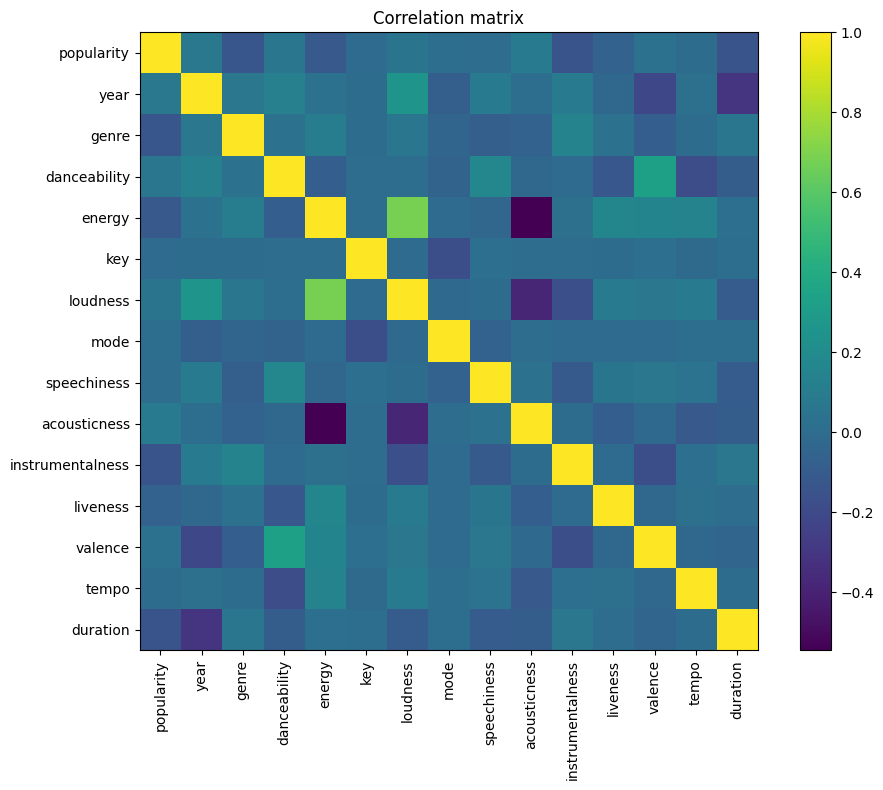

In [46]:
if len(num_cols) >= 2:
    corr = songs_data[num_cols].corr(numeric_only=True)
    fig = plt.figure(figsize=(10, 8))
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Correlation matrix")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap.")


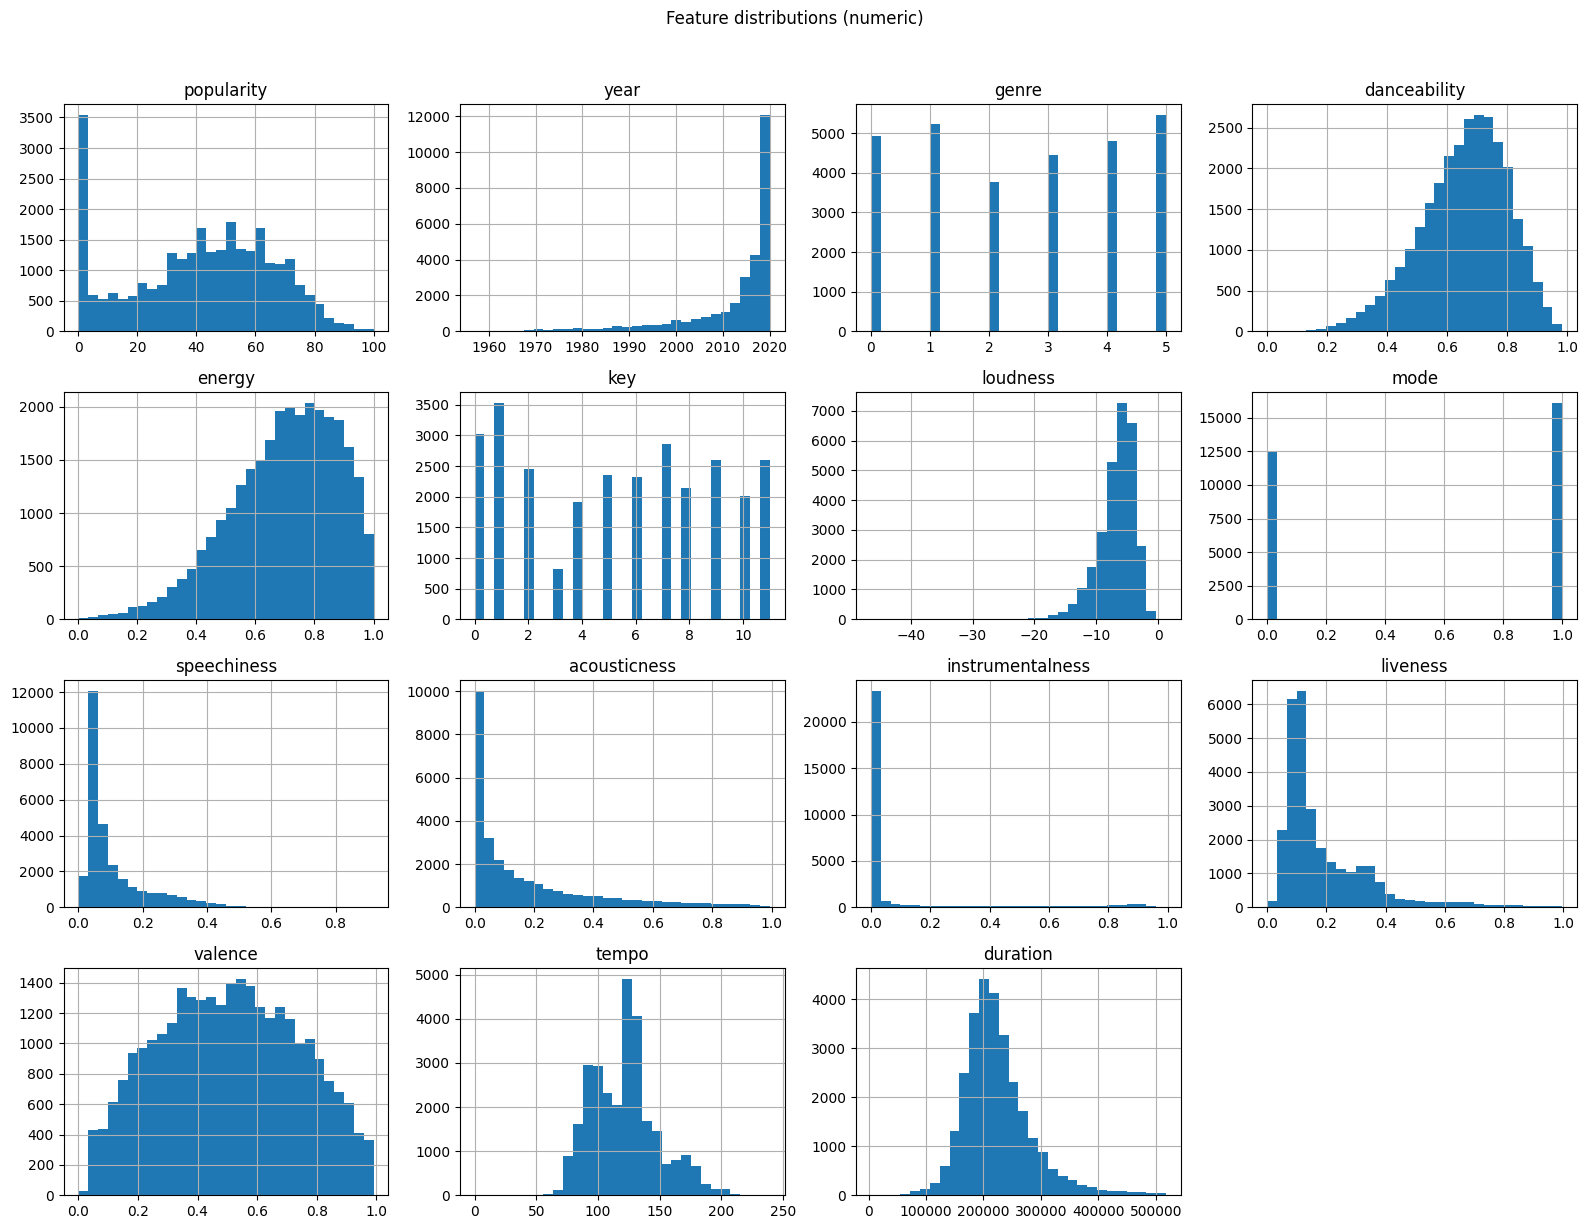

In [48]:
# Histograms (numeric features)
n = len(num_cols)
cols = 4
rows = int(np.ceil(n / cols))
plt.figure(figsize=(4*cols, 3*rows))
for i, c in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    songs_data[c].dropna().hist(bins=30)
    plt.title(c)
    plt.xlabel("")
    plt.ylabel("")
plt.suptitle("Feature distributions (numeric)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()



Detected target column: genre


,count
genre,
5,5459
1,5225
0,4931
4,4811
3,4456
2,3759


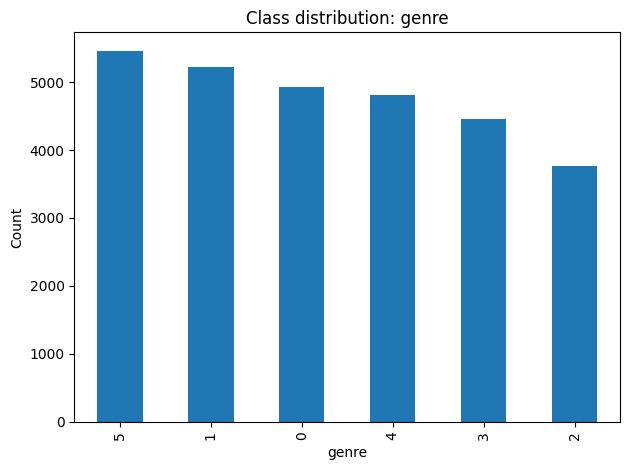

In [50]:
target_candidates = ["genre"]
target_col = next((c for c in target_candidates if c in songs_data.columns), None)
print("Detected target column:", target_col)

if target_col:
    vc = songs_data[target_col].value_counts(dropna=False)
    display(vc.to_frame("count"))
    fig = plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Class distribution: {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No typical target column found among:", target_candidates)


In [51]:
# CELL 2 — detect outliers (IQR) and winsorize (cap) them
def iqr_bounds(s: pd.Series, k: float = 1.5):
    """Return lower/upper bounds using Tukey's rule: [Q1 - k*IQR, Q3 + k*IQR]."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return low, high

def winsorize_dataframe(df: pd.DataFrame, cols, k: float = 1.5):
    """Cap values outside IQR bounds; returns new df and an outlier summary."""
    df_out = df.copy()
    summary = []
    for c in cols:
        s = pd.to_numeric(df_out[c], errors="coerce")
        low, high = iqr_bounds(s, k=k)
        # Count outliers BEFORE capping
        n_low = int((s < low).sum())
        n_high = int((s > high).sum())
        # Cap
        s_capped = s.clip(lower=low, upper=high)
        df_out[c] = s_capped
        # Count AFTER (should be zero by construction)
        n_low_after = int((df_out[c] < low).sum())
        n_high_after = int((df_out[c] > high).sum())
        summary.append({
            "column": c,
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
            "lower_bound": low,
            "upper_bound": high,
            "outliers_below_before": n_low,
            "outliers_above_before": n_high,
            "outliers_below_after": n_low_after,
            "outliers_above_after": n_high_after,
        })
    return df_out, pd.DataFrame(summary)

# Apply winsorization with k=1.5 (more aggressive) or k=3.0 (more conservative)
WINSOR_K = 1.5   # change to 3.0 if you want lighter capping
df_winsor, outlier_report = winsorize_dataframe(songs_data, num_cols, k=WINSOR_K)

print("Outlier handling done (IQR winsorization).")
outlier_report.head(12)


Outlier handling done (IQR winsorization).


,column,q1,q3,iqr,lower_bound,upper_bound,outliers_below_before,outliers_above_before,outliers_below_after,outliers_above_after
0,popularity,23.0000,60.00000,37.00000,-32.50000,115.50000,0,0,0,0
1,year,2010.0000,2019.00000,9.00000,1996.50000,2032.50000,2594,0,0,0
2,genre,1.0000,4.00000,3.00000,-3.50000,8.50000,0,0,0,0
3,danceability,0.5660,0.76200,0.19600,0.27200,1.05600,283,0,0,0
4,energy,0.5800,0.84000,0.26000,0.19000,1.23000,245,0,0,0
5,key,2.0000,9.00000,7.00000,-8.50000,19.50000,0,0,0,0
6,loudness,-8.1260,-4.64200,3.48400,-13.35200,0.58400,898,3,0,0
7,mode,0.0000,1.00000,1.00000,-1.50000,2.50000,0,0,0,0
8,speechiness,0.0415,0.13500,0.09350,-0.09875,0.27525,0,2687,0,0
9,acousticness,0.0153,0.26100,0.24570,-0.35325,0.62955,0,1895,0,0


In [52]:
# CELL 3 — Min-Max scaling on numeric features (fit on current data)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  # scales to [0, 1] by default
scaled_values = scaler.fit_transform(df_winsor[num_cols])

# Reconstruct a scaled DataFrame; keep non-numeric columns as-is
df_scaled = df_winsor.copy()
df_scaled[num_cols] = scaled_values

print("Min-Max scaling complete. Sanity check (min/max per numeric column):")
check = pd.DataFrame({
    "min": df_scaled[num_cols].min(),
    "max": df_scaled[num_cols].max()
}).round(4)
check.head(12)


Min-Max scaling complete. Sanity check (min/max per numeric column):


,min,max
popularity,0.0,1.0
year,0.0,1.0
genre,0.0,1.0
danceability,0.0,1.0
energy,0.0,1.0
key,0.0,1.0
loudness,0.0,1.0
mode,0.0,1.0
speechiness,0.0,1.0
acousticness,0.0,1.0


In [54]:
# CELL 4 — quick before/after summary (optional)
# Pick a few key numeric columns to inspect their distributions pre/post
cols_to_show = num_cols[:6]

summary_before = songs_data[cols_to_show].describe().T.add_prefix("orig_")
summary_after_winsor = df_winsor[cols_to_show].describe().T.add_prefix("winsor_")
summary_after_scaled = df_scaled[cols_to_show].describe().T.add_prefix("scaled_")

summary = pd.concat([summary_before, summary_after_winsor, summary_after_scaled], axis=1)
summary.round(4)


,orig_count,orig_mean,orig_std,orig_min,orig_25%,orig_50%,orig_75%,orig_max,winsor_count,winsor_mean,winsor_std,winsor_min,winsor_25%,winsor_50%,winsor_75%,winsor_max,scaled_count,scaled_mean,scaled_std,scaled_min,scaled_25%,scaled_50%,scaled_75%,scaled_max
popularity,28641.0,41.2738,24.3813,0.0000,23.000,44.000,60.000,100.000,28641.0,41.2738,24.3813,0.000,23.000,44.000,60.000,100.000,28641.0,0.4127,0.2438,0.0,0.2300,0.4400,0.6000,1.0
year,28641.0,2012.3049,10.1329,1957.0000,2010.000,2017.000,2019.000,2020.000,28641.0,2013.2805,7.3577,1996.500,2010.000,2017.000,2019.000,2020.000,28641.0,0.7141,0.3131,0.0,0.5745,0.8723,0.9574,1.0
genre,28641.0,2.5366,1.7681,0.0000,1.000,3.000,4.000,5.000,28641.0,2.5366,1.7681,0.000,1.000,3.000,4.000,5.000,28641.0,0.5073,0.3536,0.0,0.2000,0.6000,0.8000,1.0
danceability,28641.0,0.6569,0.1441,0.0000,0.566,0.673,0.762,0.983,28641.0,0.6574,0.1427,0.272,0.566,0.673,0.762,0.983,28641.0,0.5421,0.2007,0.0,0.4135,0.5640,0.6892,1.0
energy,28641.0,0.6975,0.1817,0.0002,0.580,0.720,0.840,1.000,28641.0,0.6980,0.1801,0.190,0.580,0.720,0.840,1.000,28641.0,0.6271,0.2224,0.0,0.4815,0.6543,0.8025,1.0
key,28641.0,5.3643,3.6159,0.0000,2.000,6.000,9.000,11.000,28641.0,5.3643,3.6159,0.000,2.000,6.000,9.000,11.000,28641.0,0.4877,0.3287,0.0,0.1818,0.5455,0.8182,1.0


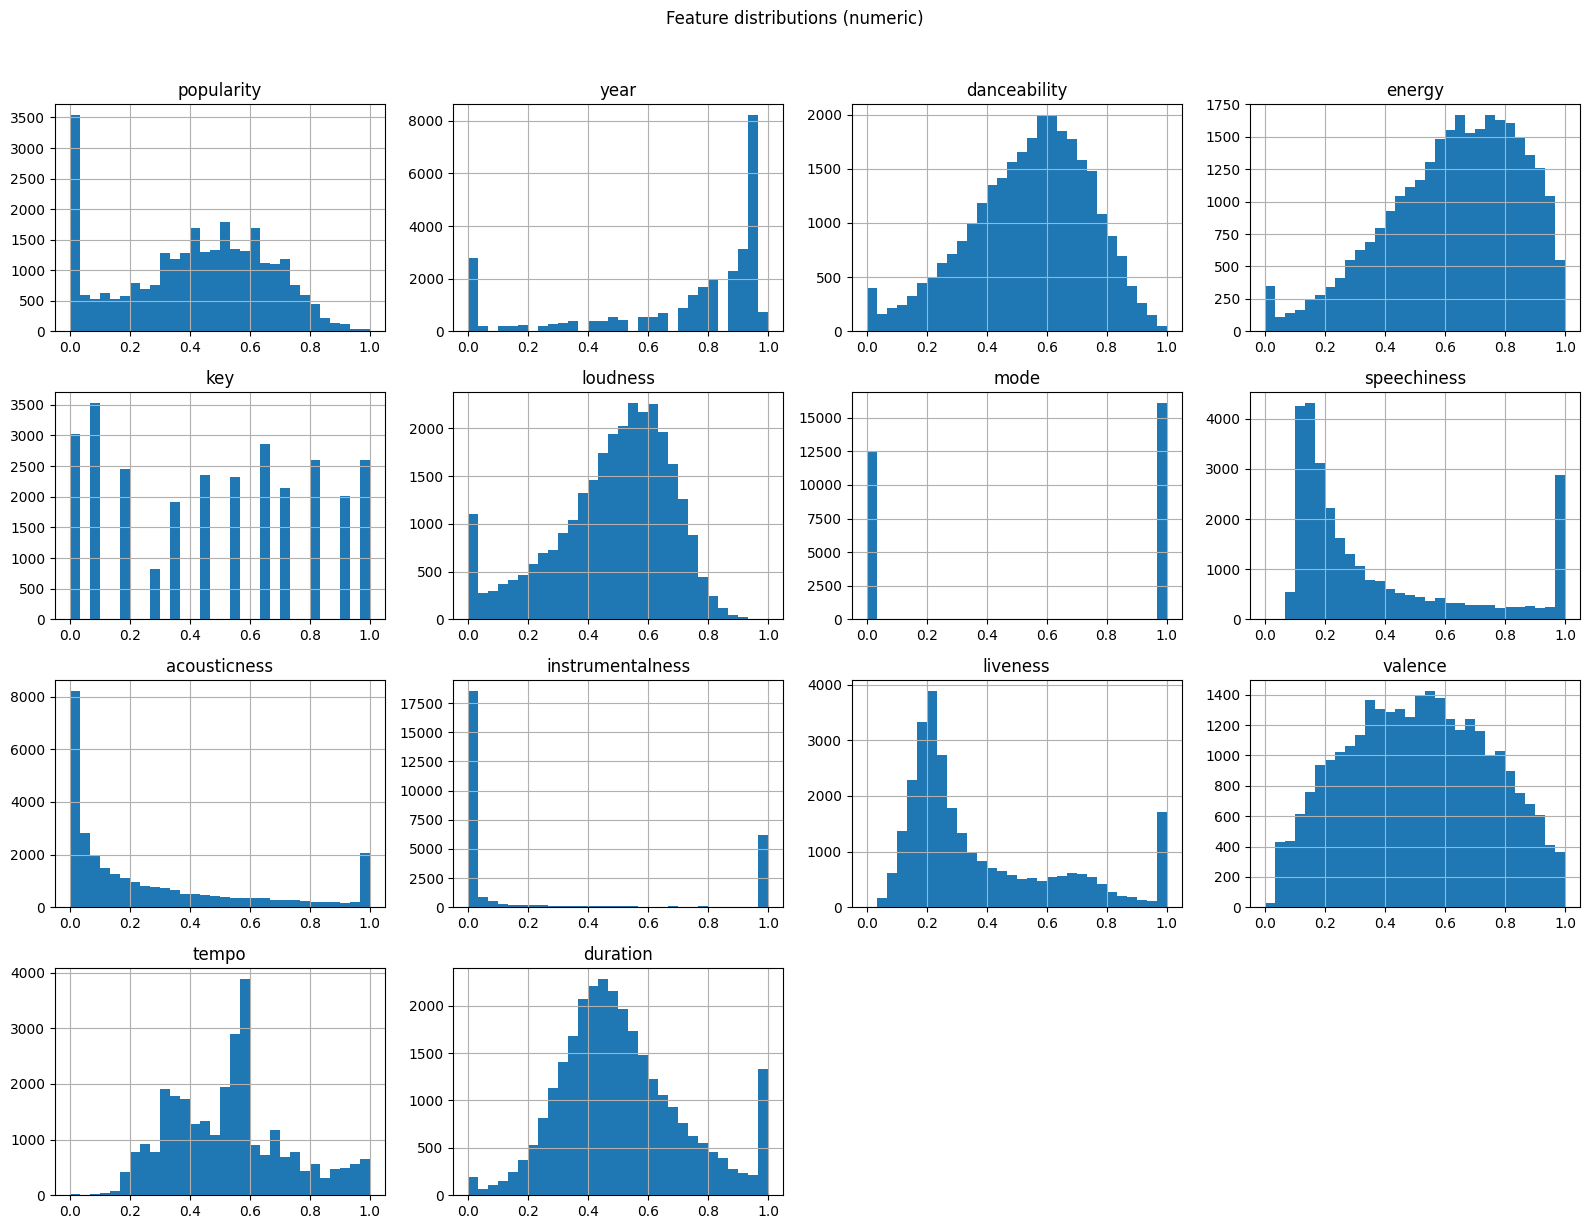

In [134]:
# Histograms (numeric features)
n = len(num_cols)
cols = 4
rows = int(np.ceil(n / cols))
plt.figure(figsize=(4*cols, 3*rows))
for i, c in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    df_scaled[c].dropna().hist(bins=30)
    plt.title(c)
    plt.xlabel("")
    plt.ylabel("")
plt.suptitle("Feature distributions (numeric)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


In [113]:

# --------------------------
# Utility functions
# --------------------------
def one_hot(y, num_classes):
    y = y.astype(int)
    oh = np.zeros((y.size, num_classes))
    oh[np.arange(y.size), y] = 1.0
    return oh

def train_val_split(X, y, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)
    n_val = int(n * val_frac)
    val_idx = idx[:n_val]
    tr_idx  = idx[n_val:]
    return X[tr_idx], y[tr_idx], X[val_idx], y[val_idx]

# --------------------------
# Activations (+ derivatives)
# --------------------------
class Activation:
    def __init__(self, kind="relu"):
        kind = kind.lower()
        assert kind in {"relu", "tanh", "sigmoid", "identity"}
        self.kind = kind

    def f(self, z):
        if self.kind == "relu":
            return np.maximum(0.0, z)
        if self.kind == "tanh":
            return np.tanh(z)
        if self.kind == "sigmoid":
            return 1.0 / (1.0 + np.exp(-z))
        return z  # identity (linear)

    def df(self, z, a=None):
        # derivative wrt z; a = f(z) optionally reused
        if self.kind == "relu":
            return (z > 0.0).astype(z.dtype)
        if self.kind == "tanh":
            if a is None: a = np.tanh(z)
            return 1.0 - a**2
        if self.kind == "sigmoid":
            if a is None: a = 1.0 / (1.0 + np.exp(-z))
            return a * (1.0 - a)
        return np.ones_like(z)

# --------------------------
# Initializers (He/Xavier)
# --------------------------
def init_weights(fan_in, fan_out, act):
    # He for ReLU, Xavier otherwise
    if act.lower() == "relu":
        scale = np.sqrt(2.0 / fan_in)
    else:
        scale = np.sqrt(1.0 / fan_in)
    W = np.random.randn(fan_in, fan_out) * scale
    b = np.zeros((1, fan_out))
    return W, b

# --------------------------
# Softmax + cross-entropy
# --------------------------
def softmax(logits):
    # logits: (N, C)
    z = logits - np.max(logits, axis=1, keepdims=True)  # numerical stability
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def cross_entropy(probs, y_true_onehot, eps=1e-12):
    # mean cross-entropy
    p = np.clip(probs, eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(p), axis=1))

# --------------------------
# MLP model
# --------------------------
class MLP:
    """
    Fully-connected MLP with configurable hidden layers and activations.
    - layers: list of layer sizes including input and output, e.g. [d_in, 64, 32, n_classes]
    - activations: list of activations for each *hidden* layer (length = len(layers)-2).
      Output uses softmax automatically.
    """
    def __init__(self, layers, activations=None, seed=42, l2=0.0):
        assert len(layers) >= 3, "Need at least input -> hidden -> output"
        self.layers = layers
        self.L = len(layers) - 1  # number of weight layers
        self.rng = np.random.default_rng(seed)
        self.l2 = float(l2)

        if activations is None:
            activations = ["relu"] * (self.L - 1)
        assert len(activations) == self.L - 1

        self.acts = [Activation(k) for k in activations]
        self.params = {}
        self._init_params()

        # for momentum
        self.vel = {f"W{i}": np.zeros_like(self.params[f"W{i}"])
                    for i in range(1, self.L + 1)}
        self.vel.update({f"b{i}": np.zeros_like(self.params[f"b{i}"])
                         for i in range(1, self.L + 1)})

    def _init_params(self):
        for i in range(1, self.L + 1):
            fan_in, fan_out = self.layers[i-1], self.layers[i]
            act = "relu" if i < self.L else "identity"
            W, b = init_weights(fan_in, fan_out, act)
            self.params[f"W{i}"] = W
            self.params[f"b{i}"] = b

    # ------------- forward -------------
    def _forward(self, X, training=False, rng=None, dropout_rates=None):
        if rng is None:
            rng = np.random.default_rng()
        if dropout_rates is None:
            dropout_rates = getattr(self, "dropout_rates", [0.0]*(self.L-1))

        A = X
        caches = []
        for i in range(1, self.L + 1):
            W, b = self.params[f"W{i}"], self.params[f"b{i}"]
            Z = A @ W + b
            if i < self.L:
                A = self.acts[i-1].f(Z)
                # inverted dropout on hidden layers
                rate = dropout_rates[i-1] if i-1 < len(dropout_rates) else 0.0
                if training and rate > 0.0:
                    keep = 1.0 - rate
                    mask = (rng.random(A.shape) < keep) / keep
                    A = A * mask
                caches.append((Z, A))
            else:
                A = softmax(Z)
                caches.append((Z, A))
        return caches

    # ------------- backward -------------
    def _backward(self, X, y_onehot, caches):
        grads = {}
        N = X.shape[0]
        # forward outputs
        A_prev = X
        for i in range(1, self.L):
            _, A_prev = caches[i-2] if i-2 >= 0 else (None, X)

        # Start with output layer: dL/dZL = (probs - y)
        ZL, AL = caches[-1]
        dZ = (AL - y_onehot) / N  # (N, C)

        for i in reversed(range(1, self.L + 1)):
            A_prev = X if i == 1 else caches[i-2][1]  # activation from previous layer
            W = self.params[f"W{i}"]

            dW = A_prev.T @ dZ  # (fan_in, fan_out)
            db = np.sum(dZ, axis=0, keepdims=True)  # (1, fan_out)

            # L2 regularization on weights (not biases)
            if self.l2 > 0:
                dW += self.l2 * W

            grads[f"dW{i}"] = dW
            grads[f"db{i}"] = db

            if i > 1:
                Z_prev, A_prev_prev = caches[i-2]
                dA_prev = dZ @ W.T  # (N, fan_in)
                gprime = self.acts[i-2].df(Z_prev, A_prev_prev)
                dZ = dA_prev * gprime

        return grads

    # ------------- loss -------------
    def _loss(self, probs, y_onehot):
        loss = cross_entropy(probs, y_onehot)
        if self.l2 > 0:
            reg = 0.0
            for i in range(1, self.L + 1):
                W = self.params[f"W{i}"]
                reg += 0.5 * self.l2 * np.sum(W * W)
            loss += reg / y_onehot.shape[0]
        return loss

    # ------------- step (SGD / momentum) -------------
    def _step(self, grads, lr=1e-2, momentum=0.0):
        for i in range(1, self.L + 1):
            for k, gkey in (("W", f"dW{i}"), ("b", f"db{i}")):
                g = grads[gkey]
                vkey = f"{k}{i}"
                self.vel[vkey] = momentum * self.vel[vkey] - lr * g
                self.params[f"{k}{i}"] += self.vel[vkey]

    # ------------- public API -------------
    # --- Patch: fit with history, early-stopping, lr decay, label smoothing ---
    def fit(self, X, y, epochs=500, batch_size=64, lr=1e-2, momentum=0.9,
            X_val=None, y_val=None, verbose=1, shuffle=True):
        N, d = X.shape
        num_classes = self.layers[-1]
        y_onehot = one_hot(y, num_classes)

        rng = np.random.default_rng()

            # History containers
        hist = {
            "train_loss": [],
            "train_acc":  [],
            "val_loss":   [],
            "val_acc":    [],
            }


        for ep in range(1, epochs + 1):
            if shuffle:
                idx = rng.permutation(N)
                X, y_onehot = X[idx], y_onehot[idx]

            # mini-batches
            for start in range(0, N, batch_size):
                end = start + batch_size
                xb = X[start:end]
                yb = y_onehot[start:end]

                caches = self._forward(xb, training=True)
                grads = self._backward(xb, yb, caches)
                self._step(grads, lr=lr, momentum=momentum)

            train_probs = self._forward(X, training = False)[-1][1]
            train_loss  = self._loss(train_probs, y_onehot)
            train_acc   = self._accuracy_from_probs(train_probs, y_onehot)

            hist["train_loss"].append(train_loss)
            hist["train_acc"].append(train_acc)

            if X_val is not None and y_val is not None:
                val_probs = self._forward(X_val, training = False)[-1][1]
                y_val_oh  = one_hot(y_val, num_classes)
                val_loss  = self._loss(val_probs, y_val_oh)
                val_acc   = self._accuracy_from_probs(val_probs, y_val_oh)
                hist["val_loss"].append(val_loss)
                hist["val_acc"].append(val_acc)
            else:
                hist["val_loss"].append(None)
                hist["val_acc"].append(None)


            # logging
            if verbose and ((ep % verbose == 0) or ep == 1 or ep == epochs):
                if X_val is not None and y_val is not None:
                    print(f"Epoch {ep:4d} | loss {train_loss:.4f} | acc {train_acc:.3f} | "
                        f"val_loss {val_loss:.4f} | val_acc {val_acc:.3f}")
                else:
                    print(f"Epoch {ep:4d} | loss {train_loss:.4f} | acc {train_acc:.3f}")
        self.history = hist
        return hist

    # Monkey-patch:

    def predict_proba(self, X):
        return self._forward(X)[-1][1]

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X, y):
        yhat = self.predict(X)
        return np.mean(yhat == y)

    @staticmethod
    def _accuracy_from_probs(probs, y_onehot):
        return np.mean(np.argmax(probs, axis=1) == np.argmax(y_onehot, axis=1))



In [114]:
def set_dropout(self, rates):
    assert len(rates) == self.L - 1
    self.dropout_rates = list(rates)
MLP.set_dropout = set_dropout


In [115]:
# Minimal Adam: add state and a switch in _step
def _init_adam(self):
    self.opt = {"t": 0}
    for i in range(1, self.L + 1):
        for k in ["W", "b"]:
            p = self.params[f"{k}{i}"]
            self.opt[f"m_{k}{i}"] = np.zeros_like(p)
            self.opt[f"v_{k}{i}"] = np.zeros_like(p)
MLP._init_adam = _init_adam

def _step_opt(self, grads, lr=1e-3, momentum=0.0, optimizer="sgd", beta1=0.9, beta2=0.999, eps=1e-8):
    if optimizer == "sgd":
        for i in range(1, self.L + 1):
            for k, gkey in (("W", f"dW{i}"), ("b", f"db{i}")):
                g = grads[gkey]
                vkey = f"{k}{i}"
                self.vel[vkey] = momentum * self.vel[vkey] - lr * g
                self.params[f"{k}{i}"] += self.vel[vkey]
    elif optimizer == "adam":
        if not hasattr(self, "opt"):
            self._init_adam()
        self.opt["t"] += 1
        t = self.opt["t"]
        for i in range(1, self.L + 1):
            for k, gkey in (("W", f"dW{i}"), ("b", f"db{i}")):
                g = grads[gkey]
                m = self.opt[f"m_{k}{i}"] = beta1 * self.opt[f"m_{k}{i}"] + (1 - beta1) * g
                v = self.opt[f"v_{k}{i}"] = beta2 * self.opt[f"v_{k}{i}"] + (1 - beta2) * (g * g)
                m_hat = m / (1 - beta1**t)
                v_hat = v / (1 - beta2**t)
                self.params[f"{k}{i}"] -= lr * m_hat / (np.sqrt(v_hat) + eps)
    else:
        raise ValueError("Unknown optimizer")
MLP._step = _step_opt


In [116]:
songs_data_dropped, outlier_report = winsorize_dataframe(songs_data, num_cols, k=WINSOR_K)

print("Outlier handling done (IQR winsorization).")
outlier_report.head(12)


Outlier handling done (IQR winsorization).


,column,q1,q3,iqr,lower_bound,upper_bound,outliers_below_before,outliers_above_before,outliers_below_after,outliers_above_after
0,popularity,23.0000,60.00000,37.00000,-32.50000,115.50000,0,0,0,0
1,year,2010.0000,2019.00000,9.00000,1996.50000,2032.50000,2594,0,0,0
2,danceability,0.5660,0.76200,0.19600,0.27200,1.05600,283,0,0,0
3,energy,0.5800,0.84000,0.26000,0.19000,1.23000,245,0,0,0
4,key,2.0000,9.00000,7.00000,-8.50000,19.50000,0,0,0,0
5,loudness,-8.1260,-4.64200,3.48400,-13.35200,0.58400,898,3,0,0
6,mode,0.0000,1.00000,1.00000,-1.50000,2.50000,0,0,0,0
7,speechiness,0.0415,0.13500,0.09350,-0.09875,0.27525,0,2687,0,0
8,acousticness,0.0153,0.26100,0.24570,-0.35325,0.62955,0,1895,0,0
9,instrumentalness,0.0000,0.00558,0.00558,-0.00837,0.01395,0,6174,0,0


In [117]:
scaled_values = scaler.fit_transform(songs_data_dropped[num_cols])

songs_data_scaled = songs_data_dropped.copy()
songs_data_scaled[num_cols] = scaled_values

print("Min-Max scaling complete. Sanity check (min/max per numeric column):")
check = pd.DataFrame({
    "min": songs_data_scaled[num_cols].min(),
    "max": songs_data_scaled[num_cols].max()
}).round(4)
check.head(12)


Min-Max scaling complete. Sanity check (min/max per numeric column):


,min,max
popularity,-1.6929,2.4087
year,-2.2807,0.9133
danceability,-2.7009,2.2818
energy,-2.8198,1.6766
key,-1.4836,1.5586
loudness,-2.4855,2.6585
mode,-1.1322,0.8833
speechiness,-1.2553,2.1785
acousticness,-0.8599,2.3562
instrumentalness,-0.6175,1.8102


In [118]:
train, test = train_test_split(songs_data_scaled, test_size=0.2, random_state=42)

X_train = train.drop(['genre'],axis=1)
y_train = train[['genre']]

X_test = test.drop(['genre'],axis=1)
y_test = test[['genre']]

num_cols = [c for c in X_train.columns if is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Numeric cols:", num_cols[:10], "..." if len(num_cols) > 10 else "")
print("Non-numeric cols (left untouched here):", cat_cols[:10], "..." if len(cat_cols) > 10 else "")

Train shape: (22912, 14), Test shape: (5729, 14)
Numeric cols: ['popularity', 'year', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness'] ...
Non-numeric cols (left untouched here): [] 


In [119]:
categorical_columns = ['year', 'key', 'mode']

X_train_categorical = X_train[categorical_columns]
X_train_numerical = X_train.drop(categorical_columns, axis=1)

X_test_categorical = X_test[categorical_columns]
X_test_numerical = X_test.drop(categorical_columns, axis=1)

scaler = StandardScaler()
X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
X_test_numerical_scaled = scaler.transform(X_test_numerical)

X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=X_train_numerical.columns, index=X_train_numerical.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=X_test_numerical.columns, index=X_test_numerical.index)

X_train_scaled = pd.concat([X_train_numerical_scaled_df, X_train_categorical], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled_df, X_test_categorical], axis=1)


In [120]:
one_hot_columns = ['year', 'key']
ct = ColumnTransformer([('one_hot_encoder', OneHotEncoder(sparse_output=False,handle_unknown='ignore'), one_hot_columns)], remainder='passthrough')

X_train_scaled = ct.fit_transform(X_train_scaled)
X_test_scaled = ct.transform(X_test_scaled)

# One-hot encode labels
y_train_series = y_train.squeeze() 
y_test_series = y_test.squeeze()
y_train = ku.to_categorical(y_train_series, num_classes=6)
y_test = ku.to_categorical(y_test_series, num_classes=6)


In [121]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(np.ravel(y_train_series))  # 1D labels
y_test_enc  = le.transform(np.ravel(y_test_series))
num_classes = len(le.classes_)
print("Classes:", le.classes_)


Classes: [0 1 2 3 4 5]


In [ ]:
input_dim = X_train_scaled.shape[1]

mlp = MLP(layers=[input_dim, 64, 16, num_classes], activations=['relu','tanh'], seed=42, l2=1e-3)

history = mlp.fit(
    X_train_scaled, y_train_enc,
    epochs=500,
    batch_size=32,  
    lr=0.001,
    momentum=0.0,
    X_val=X_test_scaled, y_val=y_test_enc,
    verbose=25,
)


Epoch    1 | loss 1.7643 | acc 0.244 | val_loss 1.7670 | val_acc 0.243
Epoch   25 | loss 1.3831 | acc 0.463 | val_loss 1.3845 | val_acc 0.464
Epoch   50 | loss 1.3319 | acc 0.483 | val_loss 1.3388 | val_acc 0.484
Epoch   75 | loss 1.2989 | acc 0.499 | val_loss 1.3100 | val_acc 0.492
Epoch  100 | loss 1.2719 | acc 0.511 | val_loss 1.2862 | val_acc 0.502
Epoch  125 | loss 1.2491 | acc 0.520 | val_loss 1.2665 | val_acc 0.514
Epoch  150 | loss 1.2306 | acc 0.528 | val_loss 1.2509 | val_acc 0.520
Epoch  175 | loss 1.2158 | acc 0.534 | val_loss 1.2387 | val_acc 0.525
Epoch  200 | loss 1.2039 | acc 0.540 | val_loss 1.2289 | val_acc 0.525
Epoch  225 | loss 1.1940 | acc 0.545 | val_loss 1.2210 | val_acc 0.528
Epoch  250 | loss 1.1853 | acc 0.547 | val_loss 1.2144 | val_acc 0.531
Epoch  275 | loss 1.1777 | acc 0.551 | val_loss 1.2089 | val_acc 0.533
Epoch  300 | loss 1.1708 | acc 0.554 | val_loss 1.2039 | val_acc 0.535
Epoch  325 | loss 1.1647 | acc 0.557 | val_loss 1.1996 | val_acc 0.536
Epoch 

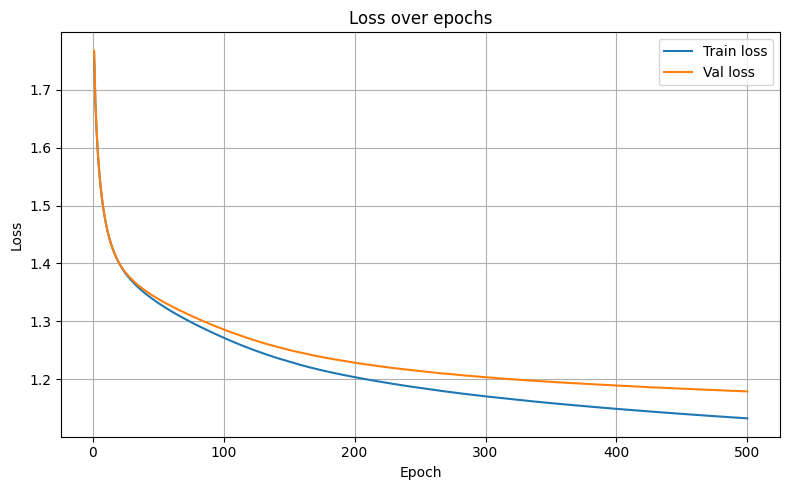

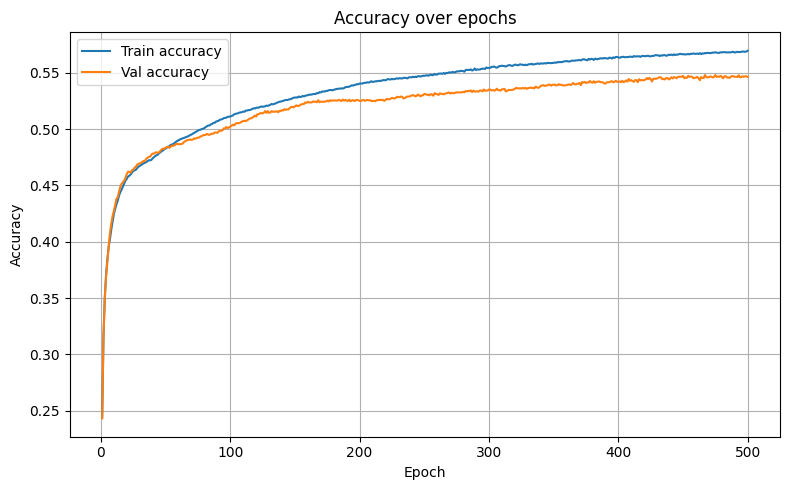

In [126]:
def plot_history(hist):
    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(epochs, hist["train_loss"], label="Train loss")
    if any(v is not None for v in hist["val_loss"]):
        # handle Nones gracefully
        val_loss = [np.nan if v is None else v for v in hist["val_loss"]]
        plt.plot(epochs, val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(epochs, hist["train_acc"], label="Train accuracy")
    if any(v is not None for v in hist["val_acc"]):
        val_acc = [np.nan if v is None else v for v in hist["val_acc"]]
        plt.plot(epochs, val_acc, label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_history(history)


Accuracy:             0.5463
Balanced Accuracy:    0.5441
Precision (macro):    0.5383
Recall    (macro):    0.5441
F1        (macro):    0.5392
Precision (weighted): 0.5386
Recall    (weighted): 0.5463
F1        (weighted): 0.5405


,class,precision,recall,f1,support
0,0,0.4063,0.4046,0.4054,959
1,1,0.5754,0.6711,0.6196,1046
2,2,0.6730,0.7249,0.6980,778
3,3,0.4328,0.3515,0.3879,879
4,4,0.5048,0.4335,0.4664,962
5,5,0.6378,0.6787,0.6576,1105



Classification report:

              precision    recall  f1-score   support

           0       0.41      0.40      0.41       959
           1       0.58      0.67      0.62      1046
           2       0.67      0.72      0.70       778
           3       0.43      0.35      0.39       879
           4       0.50      0.43      0.47       962
           5       0.64      0.68      0.66      1105

    accuracy                           0.55      5729
   macro avg       0.54      0.54      0.54      5729
weighted avg       0.54      0.55      0.54      5729



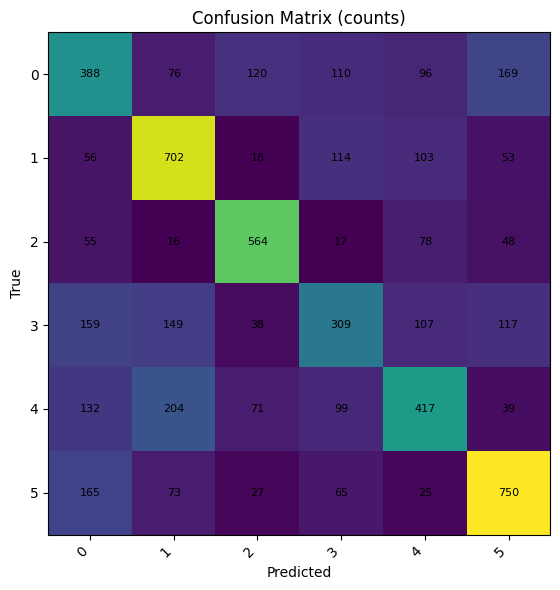

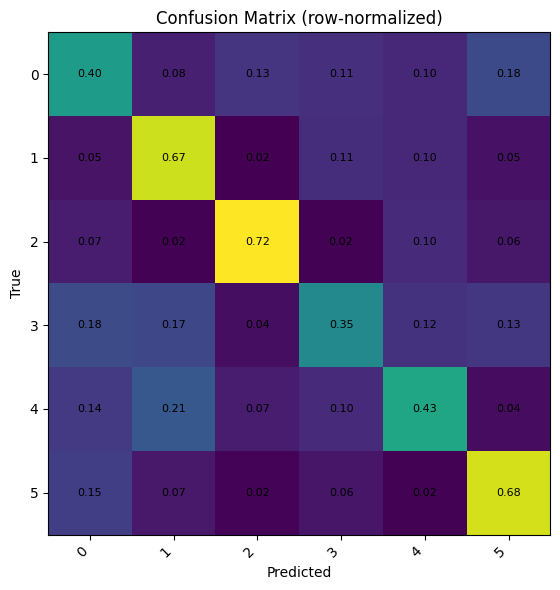

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# If your y are one-hot, collapse to class indices
def to_class_indices(y):
    if isinstance(y, pd.DataFrame):
        y = y.values
    y = np.asarray(y)
    return y.argmax(axis=1) if (y.ndim == 2 and y.shape[1] > 1) else y

y_true = to_class_indices(y_test_enc)
y_pred = mlp.predict(X_test_scaled)

# Use the labels actually present (and keep order consistent everywhere)
labels = np.unique(y_true)

# Build class names that align with labels; prefer LabelEncoder if available
try:
    # le.classes_ is ordered by encoded class index
    class_names = [str(le.classes_[i]) for i in labels]
except NameError:
    # fallback to numeric ids as strings
    class_names = [str(i) for i in labels]

# --- Global metrics ---
acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average="macro", zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average="weighted", zero_division=0
)

print(f"Accuracy:             {acc:.4f}")
print(f"Balanced Accuracy:    {bal_acc:.4f}")
print(f"Precision (macro):    {prec_macro:.4f}")
print(f"Recall    (macro):    {rec_macro:.4f}")
print(f"F1        (macro):    {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall    (weighted): {rec_weighted:.4f}")
print(f"F1        (weighted): {f1_weighted:.4f}")

# --- Per-class table ---
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average=None, zero_division=0
)
per_class = pd.DataFrame({
    "class": class_names,
    "precision": np.round(prec_c, 4),
    "recall":    np.round(rec_c, 4),
    "f1":        np.round(f1_c, 4),
    "support":   sup_c
})
display(per_class)

# --- Classification report (now with aligned string names) ---
print("\nClassification report:\n")
print(classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# --- Confusion matrices using the same labels/names ---
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

def plot_cm(mat, title, tick_names):
    fig = plt.figure(figsize=(7,6))
    plt.imshow(mat, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(tick_names)), tick_names, rotation=45, ha="right")
    plt.yticks(range(len(tick_names)), tick_names)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f"{val:.2f}" if isinstance(val, float) or np.issubdtype(mat.dtype, np.floating) else f"{val}"
            plt.text(j, i, txt, ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_cm(cm, "Confusion Matrix (counts)", class_names)
plot_cm(np.nan_to_num(cm_norm), "Confusion Matrix (row-normalized)", class_names)


In [131]:
from sklearn.dummy import DummyClassifier

dummy_mf = DummyClassifier(strategy="most_frequent")
dummy_mf.fit(X_train_scaled, y_train_enc)
y_dummy_mf = dummy_mf.predict(X_test_scaled)
print(f"Dummy (most_frequent) accuracy: {accuracy_score(y_true, y_dummy_mf):.4f}")

dummy_strat = DummyClassifier(strategy="stratified", random_state=42)
dummy_strat.fit(X_train_scaled, y_train_enc)
y_dummy_strat = dummy_strat.predict(X_test_scaled)
print(f"Dummy (stratified)    accuracy: {accuracy_score(y_true, y_dummy_strat):.4f}")


Dummy (most_frequent) accuracy: 0.1929
Dummy (stratified)    accuracy: 0.1639
